# Linear Models — M1 and M2 (Ridge)

Fits four Ridge regression variants and selects the best via rolling time-series CV.

| ID | Model | Features |
|----|-------|----------|
| M1-raw | Ridge — flags, raw target | `length_tier_ord` + complexity flags |
| M1-log | Ridge — flags, log target | Same features, target = `log(hours_creation)` |
| M2-raw | Ridge — video_type, raw target | `length_tier_ord` + `video_type` dummies |
| M2-log | Ridge — video_type, log target | Same features, target = `log(hours_creation)` |

Alpha tuned via `TimeSeriesSplit` within the training set (Layer 1 CV).
Winner selected by mean rolling CV RMSE across 3 folds (Layer 2 CV).
**Must beat B1 RMSE of 5.45h to be considered worthwhile.**

In [1]:
import duckdb
import numpy as np
import pandas as pd
import sys
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit

sys.path.append('..')
from src.constants import LENGTH_TIER_MAP, LENGTH_TIER_ORDER, LENGTH_TIER_ORDINAL

In [2]:
con = duckdb.connect('../data/workload.duckdb')
videos = con.execute('SELECT * FROM dim_videos_ml').df()
con.close()

videos_complete = videos[videos['is_complete'] == 1].reset_index(drop=True)
print(f"Total: {len(videos)} | Complete: {len(videos_complete)} | Excluded: {len(videos) - len(videos_complete)}")

Total: 126 | Complete: 98 | Excluded: 28


## Setup — Split and Feature Engineering

In [3]:
N_TEST = 25

MODEL_COLS = [
    'expected_length_mins',
    'complexity_new',
    'complexity_media_depth',
    'complexity_delivery_style',
]

df_split = (
    videos_complete[
        ['date_first', 'hours_creation', 'media_title', 'video_type', 'media_type']
        + MODEL_COLS
    ]
    .dropna(subset=['hours_creation'])
    .sort_values('date_first')
    .reset_index(drop=True)
)

n_total     = len(df_split)
cutoff_idx  = n_total - N_TEST
cutoff_date = df_split.loc[cutoff_idx, 'date_first']

train_df = df_split.iloc[:cutoff_idx].copy()
test_df  = df_split.iloc[cutoff_idx:].copy()

print(f"Train: {len(train_df)}  ({train_df['date_first'].min().date()} -> {train_df['date_first'].max().date()})")
print(f"Test:  {len(test_df)}   ({test_df['date_first'].min().date()} -> {test_df['date_first'].max().date()})")

Train: 73  (2023-02-13 -> 2025-01-20)
Test:  25   (2025-02-06 -> 2026-01-20)


In [5]:
def add_features(df):
    df = df.copy()
    df['length_tier']        = df['expected_length_mins'].astype('Int64').map(LENGTH_TIER_MAP)
    df['length_tier_ord']    = df['length_tier'].map(LENGTH_TIER_ORDINAL)
    df['log_hours_creation'] = np.log(df['hours_creation'])
    # video_type dummies for M2 — Review is the reference level (largest group, dropped)
    vtype_dummies = pd.get_dummies(df['video_type'], prefix='vtype').astype(int)
    vtype_dummies = vtype_dummies.drop(columns=['vtype_Review'], errors='ignore')
    df = pd.concat([df, vtype_dummies], axis=1)
    return df

train_df = add_features(train_df)
test_df  = add_features(test_df)

# Align dummies — test set may be missing a category seen in train so this creates the column in the case 
# where the test data doesnt
vtype_cols = [c for c in train_df.columns if c.startswith('vtype_')]
for col in vtype_cols:
    if col not in test_df.columns:
        test_df[col] = 0

print("Feature engineering complete.")
print(f"video_type dummies: {vtype_cols}")

Feature engineering complete.
video_type dummies: ['vtype_Playthrough', 'vtype_Rankings']


In [7]:
#pd.crosstab(train_df['length_tier'],train_df['length_tier_ord'])

In [8]:
#train_df[['media_title','video_type','hours_creation','log_hours_creation']]

## Feature Sets and Helpers

In [6]:
# M1 features: ordinal length tier + complexity flags
M1_FEATURES = [
    'length_tier_ord',
    'complexity_new',
    'complexity_media_depth',
    'complexity_delivery_style',
]

# M2 features: ordinal length tier + video_type dummies (Review dropped as reference)
M2_FEATURES = ['length_tier_ord'] + vtype_cols

# Alpha candidates for RidgeCV — log-spaced from very small to very large
#chose Ridge as default, Lasso zeros out coefficients and with a small feature set, this is not practical
#start at 10^-3 =.001 (almost plain OLS where coefficents totally driven by data)
#end at 10^4=10,000 (strong Ridge regularization, coefficeients almost all shrunk to 0)
#50 values in the range
ALPHAS = np.logspace(-3, 4, 50)

# Baseline to beat
B1_RMSE = 5.45

# Colour palette shared across all diagnostic plots
tier_colors = {'Short': '#4C72B0', 'Average': '#DD8452', 'Long': '#55A868'}

def rmse(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

## Layer 2 — Rolling CV (Model Selection)

Three expanding folds over the training set. For each fold, alpha is tuned via `TimeSeriesSplit` on that fold's training window (Layer 1), then RMSE is computed on the fold's test window. The mean RMSE across folds determines the winning variant.

In [7]:
def rolling_cv_ridge(train_df, features, use_log, alphas=ALPHAS, n_splits=3):
    """
    Layer 2 rolling CV for one Ridge variant.

    For each fold:
      - Layer 1: RidgeCV tunes alpha on fold's training window using TimeSeriesSplit
        - scoring='neg_root_mean_squared_error' aligns alpha selection with RMSE
        - n_splits=3 (not 5) — fold 1 trains on ~25 videos; inner min train = 25//4 = 6
      - Predicts on fold's test window
      - If use_log=True, fits on log(y) and back-transforms predictions via exp()
      - Returns per-fold RMSE in original hours scale

    Fold construction:
      - start     = int(n * 0.35)          — minimum training window (~35% of data)
      - fold_size = (n - start) // n_folds  — equal test windows tiling remaining data
      - Expanding window: each fold trains on all history up to its test window
    """
    n         = len(train_df)
    n_folds   = 3
    start     = int(n * 0.35)
    fold_size = (n - start) // n_folds

    folds = [
        (start + i * fold_size, start + (i + 1) * fold_size)
        for i in range(n_folds)
    ]

    fold_rmses = []

    for fold_idx, (test_start, test_end) in enumerate(folds):
        fold_train = train_df.iloc[:test_start].dropna(subset=features + ['hours_creation'])
        fold_test  = train_df.iloc[test_start:test_end].dropna(subset=features + ['hours_creation'])

        if len(fold_train) < 10 or len(fold_test) == 0:
            continue

        X_tr = fold_train[features].astype(float).values
        X_te = fold_test[features].astype(float).values
        y_tr = np.log(fold_train['hours_creation'].values) if use_log else fold_train['hours_creation'].values
        y_te = fold_test['hours_creation'].values  # always original scale for RMSE

        # Layer 1: tune alpha within fold's training window
        tscv   = TimeSeriesSplit(n_splits=n_splits)
        model  = RidgeCV(alphas=alphas, cv=tscv, scoring='neg_root_mean_squared_error')
        model.fit(X_tr, y_tr)

        preds = model.predict(X_te)
        if use_log:
            preds = np.exp(preds)

        fold_rmse = rmse(y_te, preds)
        fold_rmses.append(fold_rmse)
        print(f"  Fold {fold_idx+1}: train n={len(fold_train)}, test n={len(fold_test)}, alpha={model.alpha_:.4f}, RMSE={fold_rmse:.2f}h")

    mean_rmse = np.mean(fold_rmses)
    print(f"  Mean CV RMSE: {mean_rmse:.2f}h")
    return mean_rmse, fold_rmses


print("Rolling CV function defined.")

Rolling CV function defined.


In [8]:
cv_results = {}

print("── M1-raw (flags, raw target) ──────────────────")
cv_results['M1-raw'] = rolling_cv_ridge(train_df, M1_FEATURES, use_log=False)

print("\n── M1-log (flags, log target) ──────────────────")
cv_results['M1-log'] = rolling_cv_ridge(train_df, M1_FEATURES, use_log=True)

print("\n── M2-raw (video_type, raw target) ─────────────")
cv_results['M2-raw'] = rolling_cv_ridge(train_df, M2_FEATURES, use_log=False)

print("\n── M2-log (video_type, log target) ─────────────")
cv_results['M2-log'] = rolling_cv_ridge(train_df, M2_FEATURES, use_log=True)

print("\n" + "=" * 50)
print(f"  {'Variant':<12}  {'Mean CV RMSE':>14}  {'vs B1 (5.45h)':>14}")
print(f"  {'-'*12}  {'-'*14}  {'-'*14}")
for name, (mean_rmse, _) in cv_results.items():
    delta = mean_rmse - B1_RMSE
    flag  = ' BEATS B1' if mean_rmse < B1_RMSE else ''
    print(f"  {name:<12}  {mean_rmse:>13.2f}h  {delta:>+13.2f}h{flag}")
print("=" * 50)

── M1-raw (flags, raw target) ──────────────────
  Fold 1: train n=25, test n=16, alpha=7.1969, RMSE=7.87h
  Fold 2: train n=41, test n=16, alpha=1.9307, RMSE=9.22h
  Fold 3: train n=57, test n=16, alpha=0.2683, RMSE=11.15h
  Mean CV RMSE: 9.41h

── M1-log (flags, log target) ──────────────────
  Fold 1: train n=25, test n=16, alpha=3.7276, RMSE=7.84h
  Fold 2: train n=41, test n=16, alpha=1.9307, RMSE=9.15h
  Fold 3: train n=57, test n=16, alpha=0.5179, RMSE=12.84h
  Mean CV RMSE: 9.94h

── M2-raw (video_type, raw target) ─────────────
  Fold 1: train n=25, test n=16, alpha=19.3070, RMSE=9.04h
  Fold 2: train n=41, test n=16, alpha=0.1389, RMSE=9.91h
  Fold 3: train n=57, test n=16, alpha=0.3728, RMSE=9.99h
  Mean CV RMSE: 9.65h

── M2-log (video_type, log target) ─────────────
  Fold 1: train n=25, test n=16, alpha=10000.0000, RMSE=10.52h
  Fold 2: train n=41, test n=16, alpha=0.0010, RMSE=9.50h
  Fold 3: train n=57, test n=16, alpha=0.7197, RMSE=10.30h
  Mean CV RMSE: 10.10h

  Vari

## Alpha Tuning Diagnostics

RidgeCV selects alpha internally without exposing a results table. To see the full tuning landscape, we manually sweep all 50 alpha candidates using Ridge + TimeSeriesSplit on the full training set and compute mean CV RMSE at each value.

| Plot | What to look for |
|------|-----------------|
| **Validation curve (M1-raw)** | A U-shape is ideal — RMSE high at very small alpha (near-OLS, underfitted), drops to a minimum, then rises again at large alpha (over-regularised). A flat curve means regularisation strength barely matters for this dataset. The vertical line marks the alpha RidgeCV selected. |
| **M1 vs M2 comparison** | Both models on the same axes, each with its own optimal alpha marked. Shows whether the two feature sets respond differently to regularisation. |

Sweeping alphas for M1-raw...
Sweeping alphas for M2-raw...


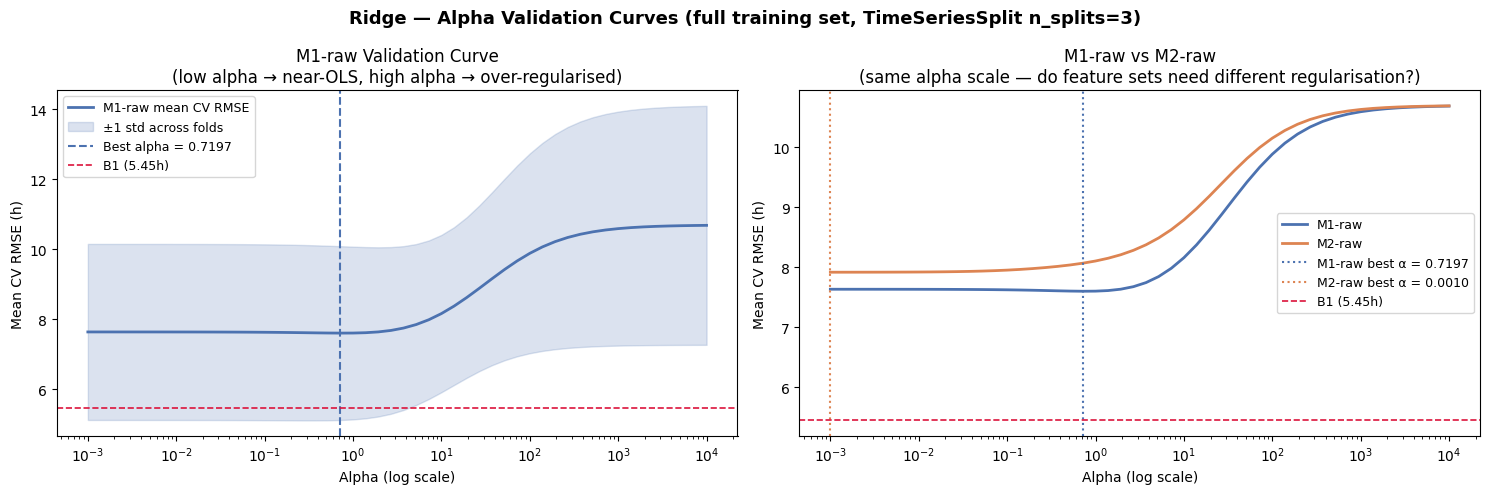


M1-raw: best alpha = 0.7197,  min mean CV RMSE = 7.60h
M2-raw: best alpha = 0.0010,  min mean CV RMSE = 7.92h

Note: RidgeCV in the rolling CV may select different alphas per fold
because it only sees that fold's training window, not the full 73 videos.


In [9]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

def alpha_validation_curve(features, use_log, alphas, label):
    """
    For each alpha, fit Ridge on full training set via TimeSeriesSplit and
    return mean CV RMSE and std across inner folds.
    Back-transforms to hours scale before computing RMSE if use_log=True.
    """
    train_clean = train_df.dropna(subset=features + ['hours_creation'])
    X = train_clean[features].astype(float).values
    y_raw = train_clean['hours_creation'].values
    y_fit = np.log(y_raw) if use_log else y_raw

    tscv = TimeSeriesSplit(n_splits=3)
    means, stds = [], []

    for alpha in alphas:
        fold_rmses = []
        for tr_idx, val_idx in tscv.split(X):
            m = Ridge(alpha=alpha).fit(X[tr_idx], y_fit[tr_idx])
            preds = m.predict(X[val_idx])
            if use_log:
                preds = np.exp(preds)
            fold_rmses.append(rmse(y_raw[val_idx], preds))
        means.append(np.mean(fold_rmses))
        stds.append(np.std(fold_rmses))

    return np.array(means), np.array(stds)


# Run sweep for M1-raw and M2-raw (the two raw-target models; log variants omitted for clarity)
print("Sweeping alphas for M1-raw...")
m1_means, m1_stds = alpha_validation_curve(M1_FEATURES, use_log=False, alphas=ALPHAS, label='M1-raw')

print("Sweeping alphas for M2-raw...")
m2_means, m2_stds = alpha_validation_curve(M2_FEATURES, use_log=False, alphas=ALPHAS, label='M2-raw')

# Best alpha for each (index of minimum mean RMSE)
m1_best_alpha = ALPHAS[m1_means.argmin()]
m2_best_alpha = ALPHAS[m2_means.argmin()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ridge — Alpha Validation Curves (full training set, TimeSeriesSplit n_splits=3)',
             fontsize=13, fontweight='bold')

# ── 1. M1-raw alone with confidence band ─────────────────────────────────────
ax = axes[0]
ax.semilogx(ALPHAS, m1_means, color='#4C72B0', linewidth=2, label='M1-raw mean CV RMSE')
ax.fill_between(ALPHAS,
                m1_means - m1_stds,
                m1_means + m1_stds,
                alpha=0.2, color='#4C72B0', label='±1 std across folds')
ax.axvline(m1_best_alpha, color='#4C72B0', linestyle='--', linewidth=1.5,
           label=f'Best alpha = {m1_best_alpha:.4f}')
ax.axhline(B1_RMSE, color='crimson', linestyle='--', linewidth=1.2, label=f'B1 ({B1_RMSE}h)')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV RMSE (h)')
ax.set_title('M1-raw Validation Curve\n(low alpha → near-OLS, high alpha → over-regularised)')
ax.legend(fontsize=9)

# ── 2. M1-raw vs M2-raw comparison ───────────────────────────────────────────
ax = axes[1]
ax.semilogx(ALPHAS, m1_means, color='#4C72B0', linewidth=2, label='M1-raw')
ax.semilogx(ALPHAS, m2_means, color='#DD8452', linewidth=2, label='M2-raw')
ax.axvline(m1_best_alpha, color='#4C72B0', linestyle=':', linewidth=1.5,
           label=f'M1-raw best α = {m1_best_alpha:.4f}')
ax.axvline(m2_best_alpha, color='#DD8452', linestyle=':', linewidth=1.5,
           label=f'M2-raw best α = {m2_best_alpha:.4f}')
ax.axhline(B1_RMSE, color='crimson', linestyle='--', linewidth=1.2, label=f'B1 ({B1_RMSE}h)')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV RMSE (h)')
ax.set_title('M1-raw vs M2-raw\n(same alpha scale — do feature sets need different regularisation?)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nM1-raw: best alpha = {m1_best_alpha:.4f},  min mean CV RMSE = {m1_means.min():.2f}h")
print(f"M2-raw: best alpha = {m2_best_alpha:.4f},  min mean CV RMSE = {m2_means.min():.2f}h")
print(f"\nNote: RidgeCV in the rolling CV may select different alphas per fold")
print(f"because it only sees that fold's training window, not the full 73 videos.")

## Final Evaluation — Holdout

Retrain the winning variant on the full training set (Layer 1 alpha tuning included), then evaluate once on the held-out 25 videos. This number is the reported model performance.

In [10]:
# ── Set winner here after reviewing CV results above ─────────────────────────
WINNER_FEATURES = M1_FEATURES   # <-- swap to M2_FEATURES if M2 wins
WINNER_LOG      = False          # <-- set True if log variant wins
WINNER_NAME     = 'M1-raw'       # <-- label for output
# ─────────────────────────────────────────────────────────────────────────────

train_clean = train_df.dropna(subset=WINNER_FEATURES + ['hours_creation'])
test_clean  = test_df.dropna(subset=WINNER_FEATURES + ['hours_creation'])

X_train = train_clean[WINNER_FEATURES].astype(float).values
X_test  = test_clean[WINNER_FEATURES].astype(float).values
y_train = np.log(train_clean['hours_creation'].values) if WINNER_LOG else train_clean['hours_creation'].values
y_test  = test_clean['hours_creation'].values

tscv          = TimeSeriesSplit(n_splits=3)
final_model   = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_root_mean_squared_error')
final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)
if WINNER_LOG:
    final_preds = np.exp(final_preds)

final_rmse = rmse(y_test, final_preds)

print(f"Winner: {WINNER_NAME}")
print(f"Tuned alpha: {final_model.alpha_:.4f}")
print(f"Holdout RMSE: {final_rmse:.2f}h  (B1 baseline: {B1_RMSE:.2f}h)")
print(f"Lift over B1: {B1_RMSE - final_rmse:.2f}h")

print(f"\nCoefficients:")
for feat, coef in zip(WINNER_FEATURES, final_model.coef_):
    print(f"  {feat:<35} {coef:+.4f}")

Winner: M1-raw
Tuned alpha: 0.7197
Holdout RMSE: 4.68h  (B1 baseline: 5.45h)
Lift over B1: 0.77h

Coefficients:
  length_tier_ord                     +4.4490
  complexity_new                      +2.9592
  complexity_media_depth              +5.8642
  complexity_delivery_style           +3.4224


## Model Serialization

Save the fitted M1-raw model to disk so the serving layer can load it without re-training.

Two files are written to `artifacts/`:
- **`m1_raw_ridge.pkl`** — the fitted `RidgeCV` object (joblib format). Contains the learned coefficients, the chosen alpha, and everything `predict()` needs.
- **`m1_raw_ridge_meta.json`** — human-readable metadata: feature names, alpha, intercept, coefficients, holdout RMSE. Used by the prediction script to validate the artifact and to generate per-flag breakdowns without needing sklearn.

In [ ]:
import joblib
import json
from pathlib import Path

ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

MODEL_NAME = 'yt_hours_ridge_v1'

# ── 1. Save the fitted model object ──────────────────────────────────────────
model_path = ARTIFACTS_DIR / f'{MODEL_NAME}.pkl'
joblib.dump(final_model, model_path)

# ── 2. Save human-readable metadata sidecar ───────────────────────────────────
meta = {
    'model_id':     MODEL_NAME,
    'model_class':  'RidgeCV',
    'target':       'hours_creation',
    'features':     WINNER_FEATURES,
    'alpha':        round(float(final_model.alpha_), 6),
    'intercept':    round(float(final_model.intercept_), 6),
    'coefficients': {
        feat: round(float(coef), 6)
        for feat, coef in zip(WINNER_FEATURES, final_model.coef_)
    },
    'holdout_rmse': round(float(final_rmse), 4),
    'b1_rmse':      B1_RMSE,
    'train_n':      int(len(X_train)),
    'test_n':       int(len(X_test)),
    'notes': (
        'Trained on videos sorted by date_first. '
        'length_tier_ord: Short=0, Average=1, Long=2. '
        'All complexity flags are binary (0/1). '
        'Rising CV fold RMSE reflects historical production maturation; '
        'process considered stable as of 2026.'
    ),
}

meta_path = ARTIFACTS_DIR / f'{MODEL_NAME}_meta.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

# ── 3. Verify round-trip ──────────────────────────────────────────────────────
loaded_model = joblib.load(model_path)
verify_preds = loaded_model.predict(X_test)
verify_rmse  = rmse(y_test, verify_preds)
assert abs(verify_rmse - final_rmse) < 1e-6, "Round-trip RMSE mismatch — artifact may be corrupt"

print(f"Saved:  {model_path}")
print(f"Saved:  {meta_path}")
print(f"Round-trip RMSE check passed: {verify_rmse:.4f}h == {final_rmse:.4f}h")
print(f"\nMetadata preview:")
print(json.dumps(meta, indent=2))

## Holdout Diagnostics

Four plots to evaluate model behaviour and flag the known distribution shift issue.

| Plot | What to look for |
|------|-----------------|
| **Actual vs Predicted** | Points close to the diagonal = good. Systematic curves = the model is missing something nonlinear. Fan shape = variance grows with hours (heteroscedasticity). |
| **Residuals over Time** | Random scatter around 0 = healthy. A drift or step change = distribution shift — the model is fit to one era of content and predicts another era. |
| **CV Fold RMSE** | Shows the degradation across folds. Bars rising toward the right means later content is harder to predict *within* the training window. The gap between the bars and the holdout line tells you how misleading the holdout RMSE is. |
| **Residuals by Length Tier** | Each tier should scatter symmetrically around 0. Tier sitting above 0 = consistently under-predicted. Tier sitting below = over-predicted. Wide spread = high within-tier variance. |

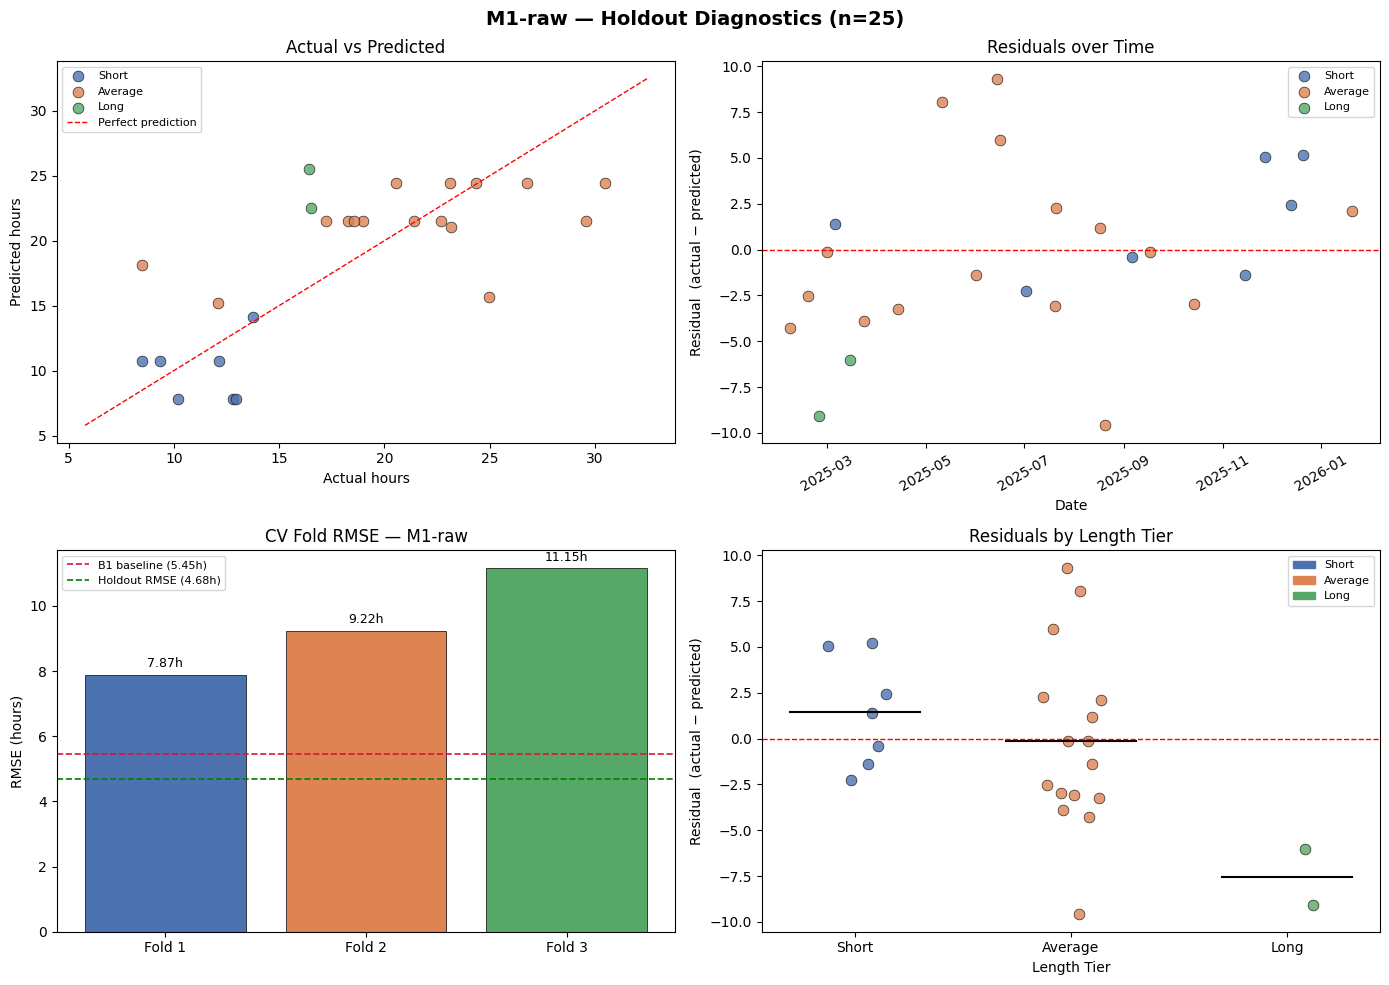


Residual summary (holdout):
  Mean residual : -0.29h  (bias — positive = under-predicted)
  Std of residuals: 4.67h

Mean residual by length tier:
  Short     n=7  mean residual=+1.43h
  Average   n=16  mean residual=-0.14h
  Long      n=2  mean residual=-7.56h


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

residuals = y_test - final_preds
tiers     = test_clean['length_tier'].values
dates     = test_clean['date_first'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{WINNER_NAME} — Holdout Diagnostics (n=25)', fontsize=14, fontweight='bold')

# ── 1. Actual vs Predicted (coloured by length tier) ─────────────────────────
ax = axes[0, 0]
for tier in LENGTH_TIER_ORDER:
    mask = tiers == tier
    ax.scatter(y_test[mask], final_preds[mask],
               color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
lim = [min(y_test.min(), final_preds.min()) - 2,
       max(y_test.max(), final_preds.max()) + 2]
ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual hours')
ax.set_ylabel('Predicted hours')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=8)

# ── 2. Residuals over Time ────────────────────────────────────────────────────
ax = axes[0, 1]
for tier in LENGTH_TIER_ORDER:
    mask = tiers == tier
    ax.scatter(dates[mask], residuals[mask],
               color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Residual  (actual − predicted)')
ax.set_title('Residuals over Time')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)

# ── 3. CV Fold RMSE vs Holdout ────────────────────────────────────────────────
ax = axes[1, 0]
winner_fold_rmses = cv_results[WINNER_NAME][1]
fold_labels = [f'Fold {i+1}' for i in range(len(winner_fold_rmses))]
bars = ax.bar(fold_labels, winner_fold_rmses,
              color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='k', linewidth=0.5)
ax.axhline(B1_RMSE,   color='crimson', linestyle='--', linewidth=1.2,
           label=f'B1 baseline ({B1_RMSE}h)')
ax.axhline(final_rmse, color='green',  linestyle='--', linewidth=1.2,
           label=f'Holdout RMSE ({final_rmse:.2f}h)')
for bar, val in zip(bars, winner_fold_rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}h', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RMSE (hours)')
ax.set_title(f'CV Fold RMSE — {WINNER_NAME}')
ax.legend(fontsize=8)

# ── 4. Residuals by Length Tier ───────────────────────────────────────────────
ax = axes[1, 1]
rng = np.random.default_rng(42)
for i, tier in enumerate(LENGTH_TIER_ORDER):
    mask = tiers == tier
    n    = mask.sum()
    jitter = rng.uniform(-0.15, 0.15, n)
    ax.scatter(np.full(n, i) + jitter, residuals[mask],
               color=tier_colors[tier], alpha=0.8,
               edgecolors='k', linewidths=0.5, s=60)
    ax.plot([i - 0.3, i + 0.3],
            [residuals[mask].mean(), residuals[mask].mean()],
            color='k', linewidth=1.5)
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xticks(range(len(LENGTH_TIER_ORDER)))
ax.set_xticklabels(LENGTH_TIER_ORDER)
ax.set_xlabel('Length Tier')
ax.set_ylabel('Residual  (actual − predicted)')
ax.set_title('Residuals by Length Tier')

patches = [mpatches.Patch(color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nResidual summary (holdout):")
print(f"  Mean residual : {residuals.mean():+.2f}h  (bias — positive = under-predicted)")
print(f"  Std of residuals: {residuals.std():.2f}h")
print(f"\nMean residual by length tier:")
for tier in LENGTH_TIER_ORDER:
    mask = tiers == tier
    if mask.sum() > 0:
        print(f"  {tier:<8}  n={mask.sum()}  mean residual={residuals[mask].mean():+.2f}h")

## Alternative Holdout — M2-raw (video_type, raw target)

M1-raw had the lowest mean CV RMSE (9.41h) but its per-fold RMSE rose sharply across folds (7.87 → 9.22 → 11.15h). This trend indicates the relationship between complexity flags and hours has drifted over time — as production matured, the same flags predict fewer hours than they did in earlier videos. A model with an unstable CV trend will not generalize reliably to future content.

M2-raw uses `video_type` dummies instead of complexity flags. Its per-fold RMSE was stable across folds (9.04 → 9.91 → 9.99h), suggesting `video_type` is a temporally consistent predictor — a Playthrough is similar work regardless of when it was made. The mean CV RMSE (9.65h) is slightly worse than M1-raw, but the stability makes M2-raw the more trustworthy choice for future predictions.

We evaluate M2-raw on the holdout set and reproduce the same diagnostics to compare.

In [12]:
m2_train_clean = train_df.dropna(subset=M2_FEATURES + ['hours_creation'])
m2_test_clean  = test_df.dropna(subset=M2_FEATURES + ['hours_creation'])

m2_X_train = m2_train_clean[M2_FEATURES].astype(float).values
m2_X_test  = m2_test_clean[M2_FEATURES].astype(float).values
m2_y_train = m2_train_clean['hours_creation'].values
m2_y_test  = m2_test_clean['hours_creation'].values

m2_tscv  = TimeSeriesSplit(n_splits=3)
m2_model = RidgeCV(alphas=ALPHAS, cv=m2_tscv, scoring='neg_root_mean_squared_error')
m2_model.fit(m2_X_train, m2_y_train)

m2_preds = m2_model.predict(m2_X_test)
m2_rmse  = rmse(m2_y_test, m2_preds)

print(f"Model: M2-raw")
print(f"Tuned alpha: {m2_model.alpha_:.4f}")
print(f"Holdout RMSE: {m2_rmse:.2f}h  (B1 baseline: {B1_RMSE:.2f}h, M1-raw: {final_rmse:.2f}h)")
print(f"Lift over B1: {B1_RMSE - m2_rmse:.2f}h")

print(f"\nCoefficients:")
for feat, coef in zip(M2_FEATURES, m2_model.coef_):
    print(f"  {feat:<35} {coef:+.4f}")

Model: M2-raw
Tuned alpha: 0.0010
Holdout RMSE: 5.49h  (B1 baseline: 5.45h, M1-raw: 4.68h)
Lift over B1: -0.04h

Coefficients:
  length_tier_ord                     +9.1540
  vtype_Playthrough                   -2.1064
  vtype_Rankings                      -11.5887


### M2-raw Diagnostics

Same four plots as M1-raw above. The key comparison is the CV fold RMSE bar chart — M2-raw's bars should be roughly flat, in contrast to M1-raw's rising bars.

| Plot | What to look for vs M1-raw |
|------|---------------------------|
| **Actual vs Predicted** | Is the scatter tighter or looser around the diagonal? |
| **Residuals over Time** | Is the residual pattern more stable with less drift? |
| **CV Fold RMSE** | Bars should be roughly flat — the stability that justified this choice |
| **Residuals by Length Tier** | Compare bias per tier — does M2 shift which tiers are under/over-predicted? |

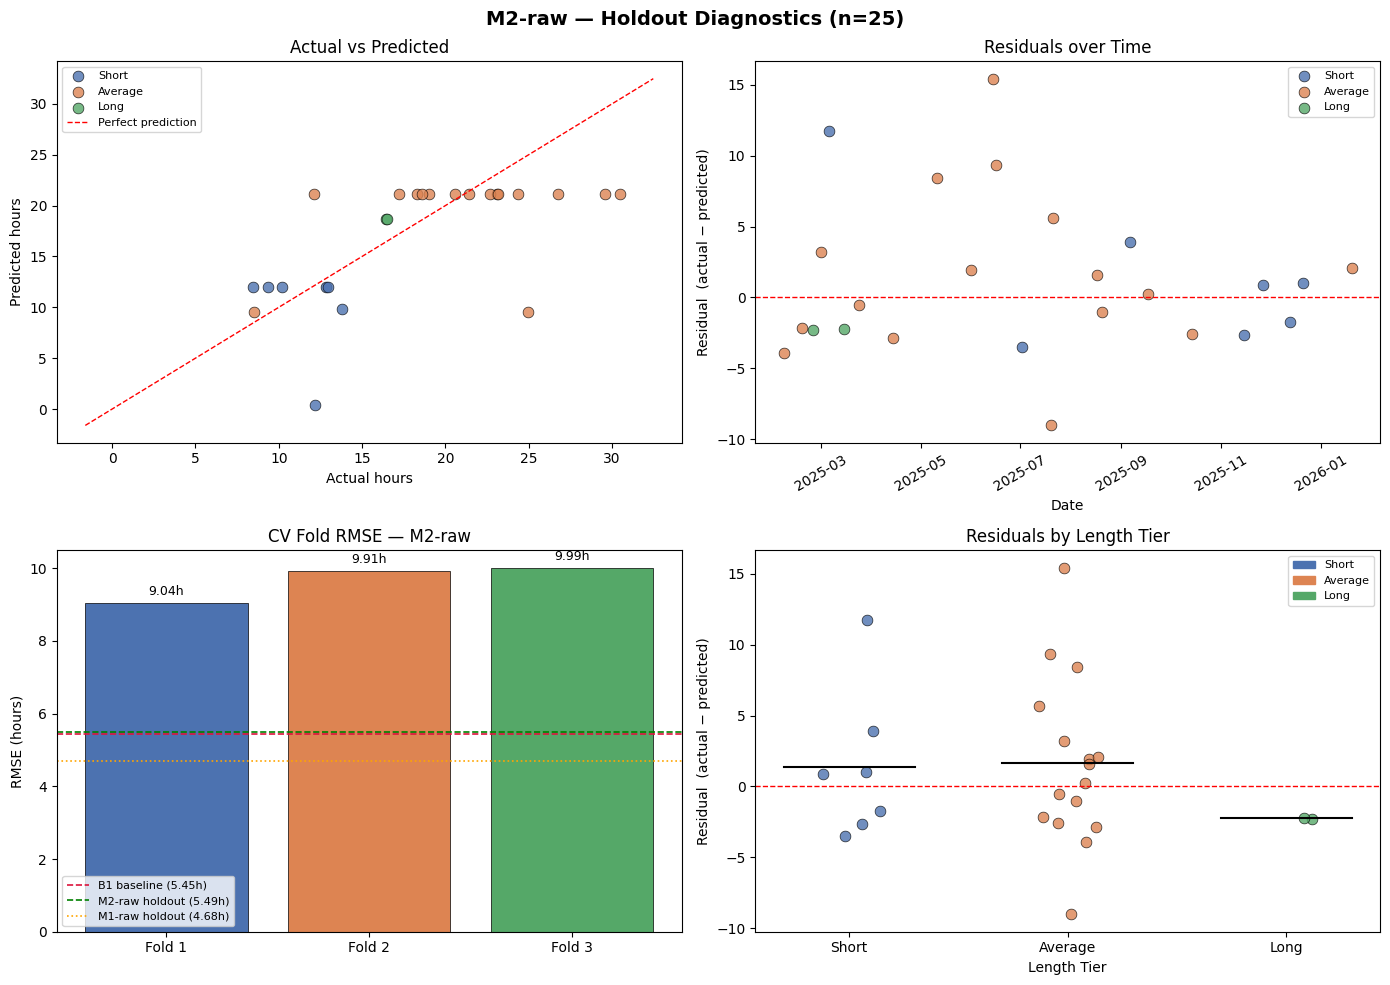


Residual summary (M2-raw holdout):
  Mean residual:    +1.24h  (bias — positive = under-predicted)
  Std of residuals: 5.35h

Mean residual by length tier:
  Short     n=7  mean residual=+1.37h
  Average   n=16  mean residual=+1.61h
  Long      n=2  mean residual=-2.24h

  Model comparison (holdout):
  M1-raw  RMSE: 4.68h  (CV trend: rising)
  M2-raw  RMSE: 5.49h  (CV trend: stable)
  B1      RMSE: 5.45h  (success criterion)


In [13]:
m2_residuals = m2_y_test - m2_preds
m2_tiers     = m2_test_clean['length_tier'].values
m2_dates     = m2_test_clean['date_first'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'M2-raw — Holdout Diagnostics (n=25)', fontsize=14, fontweight='bold')

# ── 1. Actual vs Predicted ────────────────────────────────────────────────────
ax = axes[0, 0]
for tier in LENGTH_TIER_ORDER:
    mask = m2_tiers == tier
    ax.scatter(m2_y_test[mask], m2_preds[mask],
               color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
lim = [min(m2_y_test.min(), m2_preds.min()) - 2,
       max(m2_y_test.max(), m2_preds.max()) + 2]
ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual hours')
ax.set_ylabel('Predicted hours')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=8)

# ── 2. Residuals over Time ────────────────────────────────────────────────────
ax = axes[0, 1]
for tier in LENGTH_TIER_ORDER:
    mask = m2_tiers == tier
    ax.scatter(m2_dates[mask], m2_residuals[mask],
               color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Residual  (actual − predicted)')
ax.set_title('Residuals over Time')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)

# ── 3. CV Fold RMSE vs Holdout ────────────────────────────────────────────────
ax = axes[1, 0]
m2_fold_rmses = cv_results['M2-raw'][1]
fold_labels = [f'Fold {i+1}' for i in range(len(m2_fold_rmses))]
bars = ax.bar(fold_labels, m2_fold_rmses,
              color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='k', linewidth=0.5)
ax.axhline(B1_RMSE, color='crimson', linestyle='--', linewidth=1.2,
           label=f'B1 baseline ({B1_RMSE}h)')
ax.axhline(m2_rmse, color='green', linestyle='--', linewidth=1.2,
           label=f'M2-raw holdout ({m2_rmse:.2f}h)')
ax.axhline(final_rmse, color='orange', linestyle=':', linewidth=1.2,
           label=f'M1-raw holdout ({final_rmse:.2f}h)')
for bar, val in zip(bars, m2_fold_rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}h', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RMSE (hours)')
ax.set_title('CV Fold RMSE — M2-raw')
ax.legend(fontsize=8)

# ── 4. Residuals by Length Tier ───────────────────────────────────────────────
ax = axes[1, 1]
rng = np.random.default_rng(42)
for i, tier in enumerate(LENGTH_TIER_ORDER):
    mask = m2_tiers == tier
    n    = mask.sum()
    jitter = rng.uniform(-0.15, 0.15, n)
    ax.scatter(np.full(n, i) + jitter, m2_residuals[mask],
               color=tier_colors[tier], alpha=0.8,
               edgecolors='k', linewidths=0.5, s=60)
    ax.plot([i - 0.3, i + 0.3],
            [m2_residuals[mask].mean(), m2_residuals[mask].mean()],
            color='k', linewidth=1.5)
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xticks(range(len(LENGTH_TIER_ORDER)))
ax.set_xticklabels(LENGTH_TIER_ORDER)
ax.set_xlabel('Length Tier')
ax.set_ylabel('Residual  (actual − predicted)')
ax.set_title('Residuals by Length Tier')

patches = [mpatches.Patch(color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nResidual summary (M2-raw holdout):")
print(f"  Mean residual:    {m2_residuals.mean():+.2f}h  (bias — positive = under-predicted)")
print(f"  Std of residuals: {m2_residuals.std():.2f}h")
print(f"\nMean residual by length tier:")
for tier in LENGTH_TIER_ORDER:
    mask = m2_tiers == tier
    if mask.sum() > 0:
        print(f"  {tier:<8}  n={mask.sum()}  mean residual={m2_residuals[mask].mean():+.2f}h")

print(f"\n{'='*45}")
print(f"  Model comparison (holdout):")
print(f"  M1-raw  RMSE: {final_rmse:.2f}h  (CV trend: rising)")
print(f"  M2-raw  RMSE: {m2_rmse:.2f}h  (CV trend: stable)")
print(f"  B1      RMSE: {B1_RMSE:.2f}h  (success criterion)")
print(f"{'='*45}")

In [14]:
# ── M2-log holdout — needed for QQ plot comparison ───────────────────────────
m2log_train_clean = train_df.dropna(subset=M2_FEATURES + ['hours_creation'])
m2log_test_clean  = test_df.dropna(subset=M2_FEATURES + ['hours_creation'])

m2log_X_train = m2log_train_clean[M2_FEATURES].astype(float).values
m2log_X_test  = m2log_test_clean[M2_FEATURES].astype(float).values
m2log_y_train = np.log(m2log_train_clean['hours_creation'].values)
m2log_y_test  = m2log_test_clean['hours_creation'].values

m2log_tscv  = TimeSeriesSplit(n_splits=3)
m2log_model = RidgeCV(alphas=ALPHAS, cv=m2log_tscv, scoring='neg_root_mean_squared_error')
m2log_model.fit(m2log_X_train, m2log_y_train)

m2log_preds_log  = m2log_model.predict(m2log_X_test)   # predictions in log space
m2log_preds      = np.exp(m2log_preds_log)              # back-transformed to hours
m2log_rmse       = rmse(m2log_y_test, m2log_preds)

print(f"M2-log holdout RMSE: {m2log_rmse:.2f}h  (M2-raw: {m2_rmse:.2f}h, B1: {B1_RMSE:.2f}h)")

M2-log holdout RMSE: 5.63h  (M2-raw: 5.49h, B1: 5.45h)


## QQ Plot — M2-raw vs M2-log

A QQ (quantile-quantile) plot tests whether residuals follow a normal distribution. The x-axis is the theoretical quantiles of a standard normal distribution; the y-axis is the actual quantiles of your residuals. If the residuals are perfectly normal, every point falls exactly on the diagonal line.

**What deviations mean:**
- **Upper-right points above the line** — large positive residuals are bigger than a normal distribution predicts. The model is under-predicting your longest/most complex videos by more than expected (heavy right tail).
- **Lower-left points below the line** — large negative residuals are more extreme than expected (heavy left tail).
- **S-curve shape** — residuals are light-tailed (less extreme than normal). Usually not a problem.
- **Points curving away at both ends** — residuals are heavy-tailed (both over- and under-predictions are worse than normal predicts).

**Why compare raw vs log:**
Linear regression assumes the residuals in the fitting space are normally distributed. For M2-raw, that's residuals in hours. For M2-log, that's residuals in log-hours — `log(actual) − log(predicted)` — which is equivalent to the log of the prediction ratio. `hours_creation` is right-skewed (a few very long videos), so the raw residuals will likely show a heavy right tail. The log transformation is meant to symmetrise that distribution. If the M2-log QQ plot is closer to the diagonal, the log model's assumption is better justified.

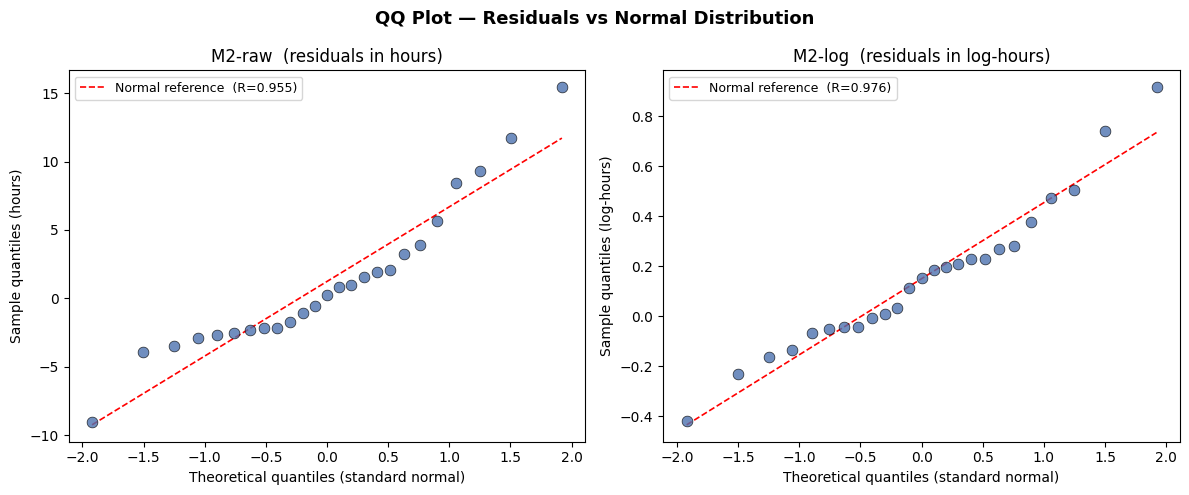

R closer to 1.0 = residuals more normally distributed.
  M2-raw  R: 0.9549
  M2-log  R: 0.9756


In [15]:
from scipy import stats

# M2-raw residuals: original hours scale
raw_resid = m2_y_test - m2_preds

# M2-log residuals: log space (where normality is assumed)
log_resid = np.log(m2log_y_test) - m2log_preds_log

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('QQ Plot — Residuals vs Normal Distribution', fontsize=13, fontweight='bold')

for ax, resid, title, unit in [
    (axes[0], raw_resid, 'M2-raw  (residuals in hours)',    'hours'),
    (axes[1], log_resid, 'M2-log  (residuals in log-hours)', 'log-hours'),
]:
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, color='#4C72B0', alpha=0.8, edgecolors='k', linewidths=0.5, s=60, zorder=3)
    line_x = np.array([osm[0], osm[-1]])
    ax.plot(line_x, slope * line_x + intercept, 'r--', linewidth=1.2, label=f'Normal reference  (R={r:.3f})')
    ax.set_xlabel('Theoretical quantiles (standard normal)')
    ax.set_ylabel(f'Sample quantiles ({unit})')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("R closer to 1.0 = residuals more normally distributed.")
print(f"  M2-raw  R: {stats.probplot(raw_resid, dist='norm')[1][2]:.4f}")
print(f"  M2-log  R: {stats.probplot(log_resid, dist='norm')[1][2]:.4f}")